In [1]:
import sys
sys.path.insert(0, "../src/fg_removal_pipe")  # add Folder_2 path to search list
import diff_removal as bss
from Jybeam_2_K import TFromJyBeam
from power_spectrum import cyclindircal_powerspec
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

column_width=240# call "\the\columnwidth" in LaTeX to find
ppi=72#default ppi, can be left the same

scale=2
fig_width=column_width/ppi*scale#inches
fig_height=3*scale#inches

##SET FONT SIZES
font_small_size = 9
font_medium_size = 12
font_bigger_size =14

plt.rc('font', size=font_small_size) # controls default text sizes
plt.rc('axes', titlesize=font_small_size) # fontsize of the axes title
plt.rc('axes', labelsize=font_medium_size) # fontsize of the x and y labels
plt.rc('xtick', labelsize=font_bigger_size) # fontsize of the tick labels
plt.rc('ytick', labelsize=font_bigger_size) # fontsize of the tick labels
plt.rc('legend', fontsize=font_small_size) # legend fontsize
plt.rc('figure', titlesize=font_bigger_size)

base = '/home/ppxjf3/repos/Foreground_Removal_Pipeline/'

In [2]:
#open all fits images and make into numpy array

num = 44
init = 525
bss_data = np.zeros([1024,1024,num])
for ii in range(0,num):

    fits_path = base + 'data/ZW3_BSS_0'+str(init+ii)+'-image.fits'

    hdul = fits.open(fits_path)

    img = np.squeeze(hdul[0].data)
    bss_data[:,:,ii] = img
    hdul.info()
    hdul.close()

Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0525-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0526-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0527-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0528-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0529-image.fits
No.    Name      Ver    Ty

In [3]:
#convert to K from Jy/beam
nu = np.arange(158.5, 158.5+(num-1)*0.1, 0.1)
print(nu)
#beam size
bmaj = 0.0441365996677112
bmin = 0.032916727852457

bss_data_K = TFromJyBeam(bss_data, bmaj, bmin, nu)

[158.5 158.6 158.7 158.8 158.9 159.  159.1 159.2 159.3 159.4 159.5 159.6
 159.7 159.8 159.9 160.  160.1 160.2 160.3 160.4 160.5 160.6 160.7 160.8
 160.9 161.  161.1 161.2 161.3 161.4 161.5 161.6 161.7 161.8 161.9 162.
 162.1 162.2 162.3 162.4 162.5 162.6 162.7 162.8]


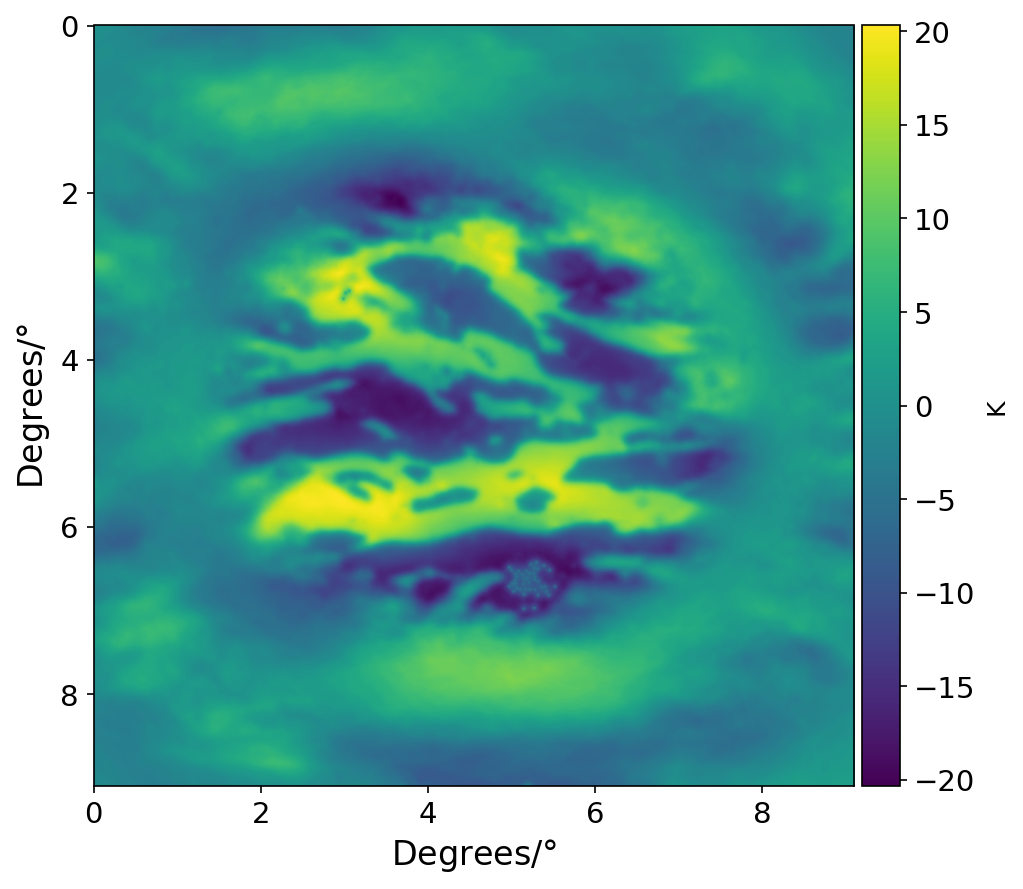

In [4]:
#look at images in K and Jy/beam

mpl.rcParams['figure.dpi'] = 300/scale
# Set up a figure with four panels, with two rows and columns
fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=1, ncols=1,)
pmc = ax.imshow(bss_data_K[:,:,0], extent=[0,9.1,9.1,0.0])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(pmc, cax=cax, orientation='vertical', label='K')
ax.set_ylabel(r'$\rm Degrees / \degree$', fontsize=16)
ax.set_xlabel(r'$\rm Degrees / \degree$', fontsize=16)
plt.tight_layout()
plt.savefig(base + 'plots/after_brightsourceremoval.pdf', dpi=330)
plt.show()


In [5]:
#cut to central 4 degrees (512 by 512)
i0 = 512//2
i1 = 1024 - (512//2)

#FastICA
mod_fICA, res_fICA = bss.fastica(bss_data_K[i0:i1,i0:i1,:], 4)

#GPR
#mod_GPR, res_GPR, res = bss.GPR(bss_data_K[i0:i1,i0:i1,:], nu)  

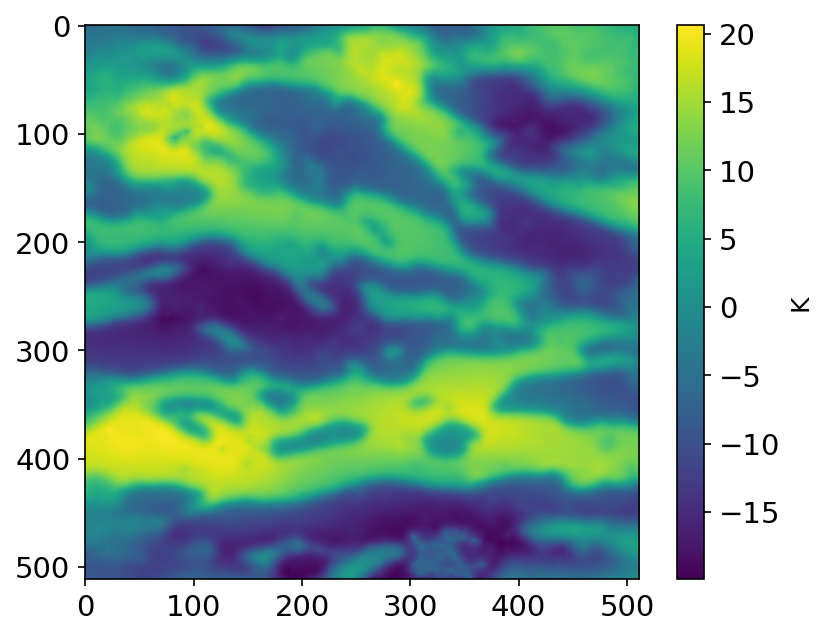

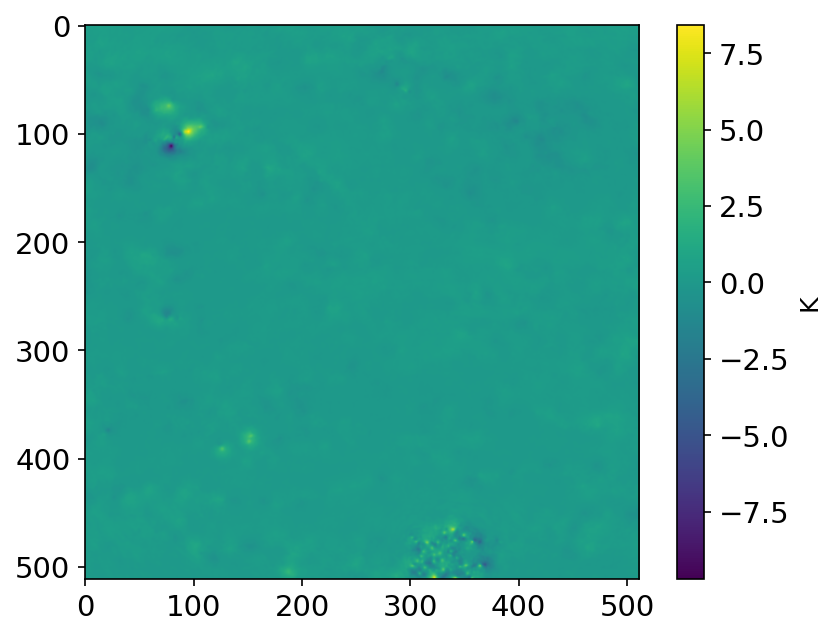

"plt.imshow(mod_GPR[:,:,0])\nplt.colorbar(label='K')\nplt.show()\nplt.imshow(res_GPR[:,:,0])\nplt.colorbar(label='K')\nplt.show()\nplt.imshow(res[:,:,0])\nplt.colorbar(label='K')\nplt.show()"

In [6]:

plt.imshow(mod_fICA[:,:,0])
plt.colorbar(label='K')
plt.show()
plt.figure()
plt.imshow(res_fICA[:,:,0])
plt.colorbar(label='K')
plt.show()

"""plt.imshow(mod_GPR[:,:,0])
plt.colorbar(label='K')
plt.show()
plt.imshow(res_GPR[:,:,0])
plt.colorbar(label='K')
plt.show()
plt.imshow(res[:,:,0])
plt.colorbar(label='K')
plt.show()"""

In [7]:
#get bin edges as defined by the data challenge
filename_kpar = "/home/ppxjf3/SKAO_DATA_CHALLENGE/bins_kpar.txt"
kpar_bins_skao = np.loadtxt(filename_kpar)

filename_kper = "/home/ppxjf3/SKAO_DATA_CHALLENGE/bins_kper.txt"
kper_bins_skao = np.loadtxt(filename_kper)

kbins_skao = [kper_bins_skao, kpar_bins_skao] #bin centers

dkper = kper_bins_skao[1] - kper_bins_skao[0]
dkpar = kpar_bins_skao[1] - kpar_bins_skao[0]
kper_edges_skao = np.arange(len(kper_bins_skao)+1) * dkper + (kper_bins_skao[0] - 0.5 * dkper)
kpar_edges_skao = np.arange(len(kpar_bins_skao)+1) * dkpar + (kpar_bins_skao[0] - 0.5 * dkpar)

kbins_edges = [kper_edges_skao[:-2], kpar_edges_skao[:-2]] # bin edges
print(kbins_edges)

[array([0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425]), array([0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425])]


Filename: /home/ppxjf3/SKAO_DATA_CHALLENGE/EoR_H21cm_v9.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (512, 512, 936)   float32   
(43, 512, 512)


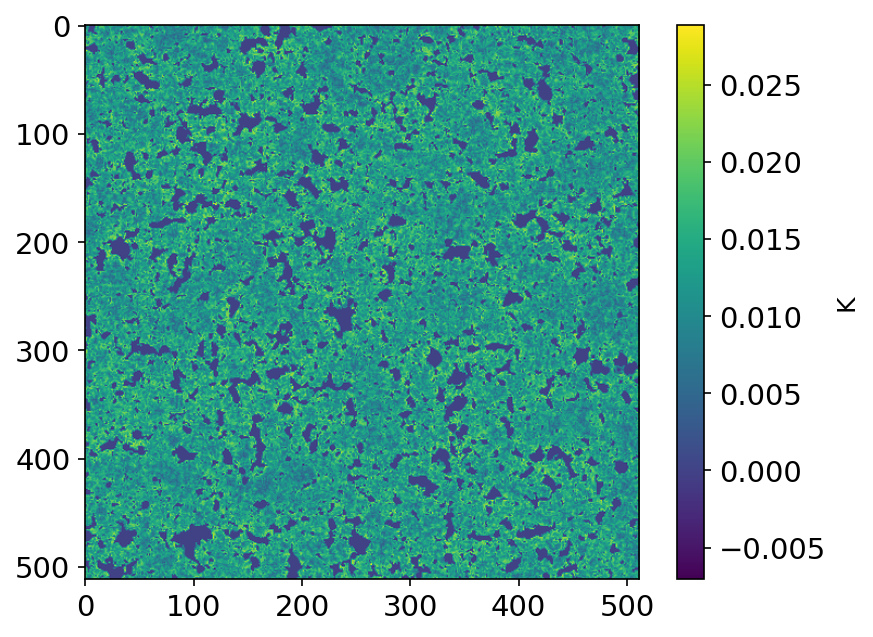

In [ ]:
#compare to the truth!!
with fits.open('/home/ppxjf3/SKAO_DATA_CHALLENGE/EoR_H21cm_v9.fits', memmap=True) as hdu:
    truth = np.array(hdu[0].data[525:569,:,:])
    hdu.info()

print(truth.shape)
plt.imshow(truth[0,:,:])
plt.colorbar(label='K')
plt.show()


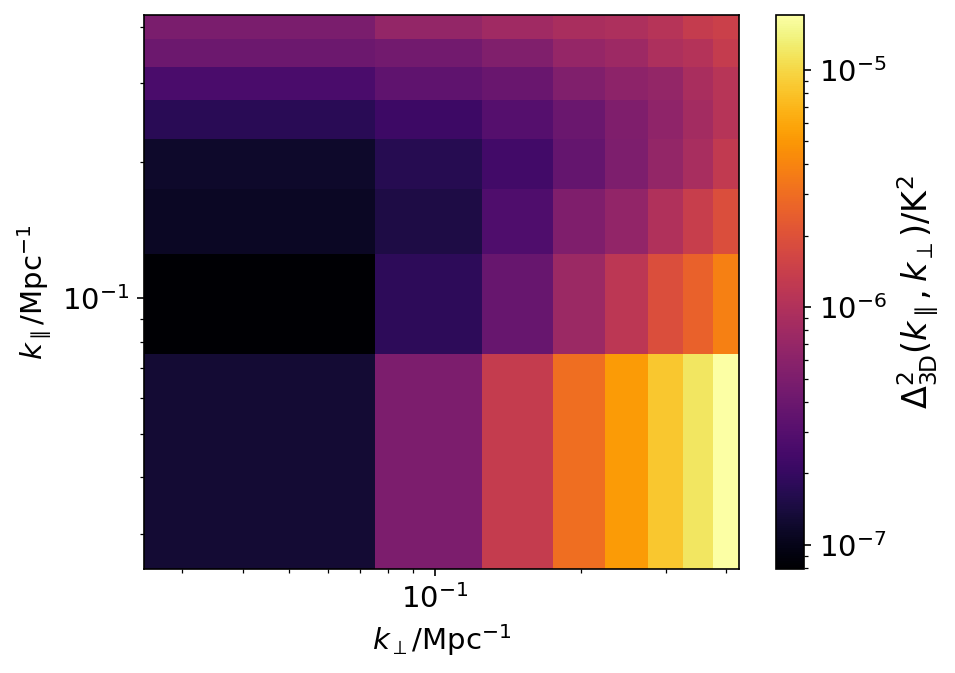

In [17]:
from scipy import interpolate
import matplotlib.colors as colors
import tools21cm as t2c

#make power spectra FastICA
plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

pp_truth, kper, kpar= t2c.power_spectrum_2d(truth,  binning = 'linear', kbins=kbins_edges, nu_axis=0, return_modes=False)


#normalise to dimensionless power spectrum
for ii in range(0,len(kper)):
    for jj in range(0,len(kpar)):
        pp_truth[ii,jj] = (pp_truth[ii,jj]*np.sqrt(kper[ii]**2+kpar[jj]**2)**3)/(2*np.pi**2)
  
fp = interpolate.interp2d(kper, kpar, pp_truth.T, kind='linear')
CC_truth = fp(kper,kpar)
norm_truth = colors.LogNorm(vmin=CC_truth[np.isfinite(CC_truth)].min(), vmax=CC_truth[np.isfinite(CC_truth)].max()) if plotting_scale['z']=='log' else None 


pcm = plt.pcolormesh(kper, kpar, CC_truth, norm=norm_truth, cmap='inferno')
cbar= plt.colorbar(pcm)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm K^2 $', size=16) 
plt.xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
plt.ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
plt.xscale(plotting_scale['x'])
plt.yscale(plotting_scale['y'])
plt.show()

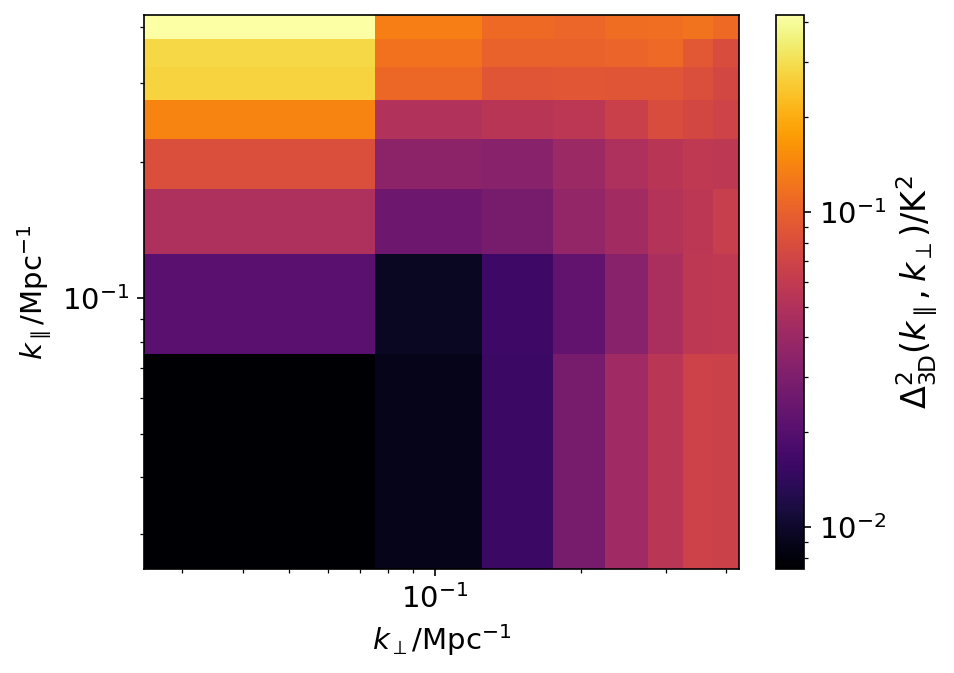

In [18]:
import tools21cm as t2c
from scipy import interpolate
import matplotlib.colors as colors

#make power spectra FastICA
plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

pp_res, kper, kpar= t2c.power_spectrum_2d(res_fICA,  binning = 'linear', kbins=kbins_edges, return_modes=False)


#normalise to dimensionless power spectrum
for ii in range(0,len(kper)):
    for jj in range(0,len(kpar)):
        pp_res[ii,jj] = (pp_res[ii,jj]*np.sqrt(kper[ii]**2+kpar[jj]**2)**3)/(2*np.pi**2)
  
fp = interpolate.interp2d(kper, kpar, pp_res.T, kind='linear')
CC_res = fp(kper,kpar)

norm_res = colors.LogNorm(vmin=CC_res[np.isfinite(CC_res)].min(), vmax=CC_res[np.isfinite(CC_res)].max()) if plotting_scale['z']=='log' else None 


pcm = plt.pcolormesh(kper, kpar, CC_res, norm=norm_res, cmap='inferno')
cbar= plt.colorbar(pcm)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm K^2 $', size=16) 
plt.xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
plt.ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
plt.xscale(plotting_scale['x'])
plt.yscale(plotting_scale['y'])
plt.show()

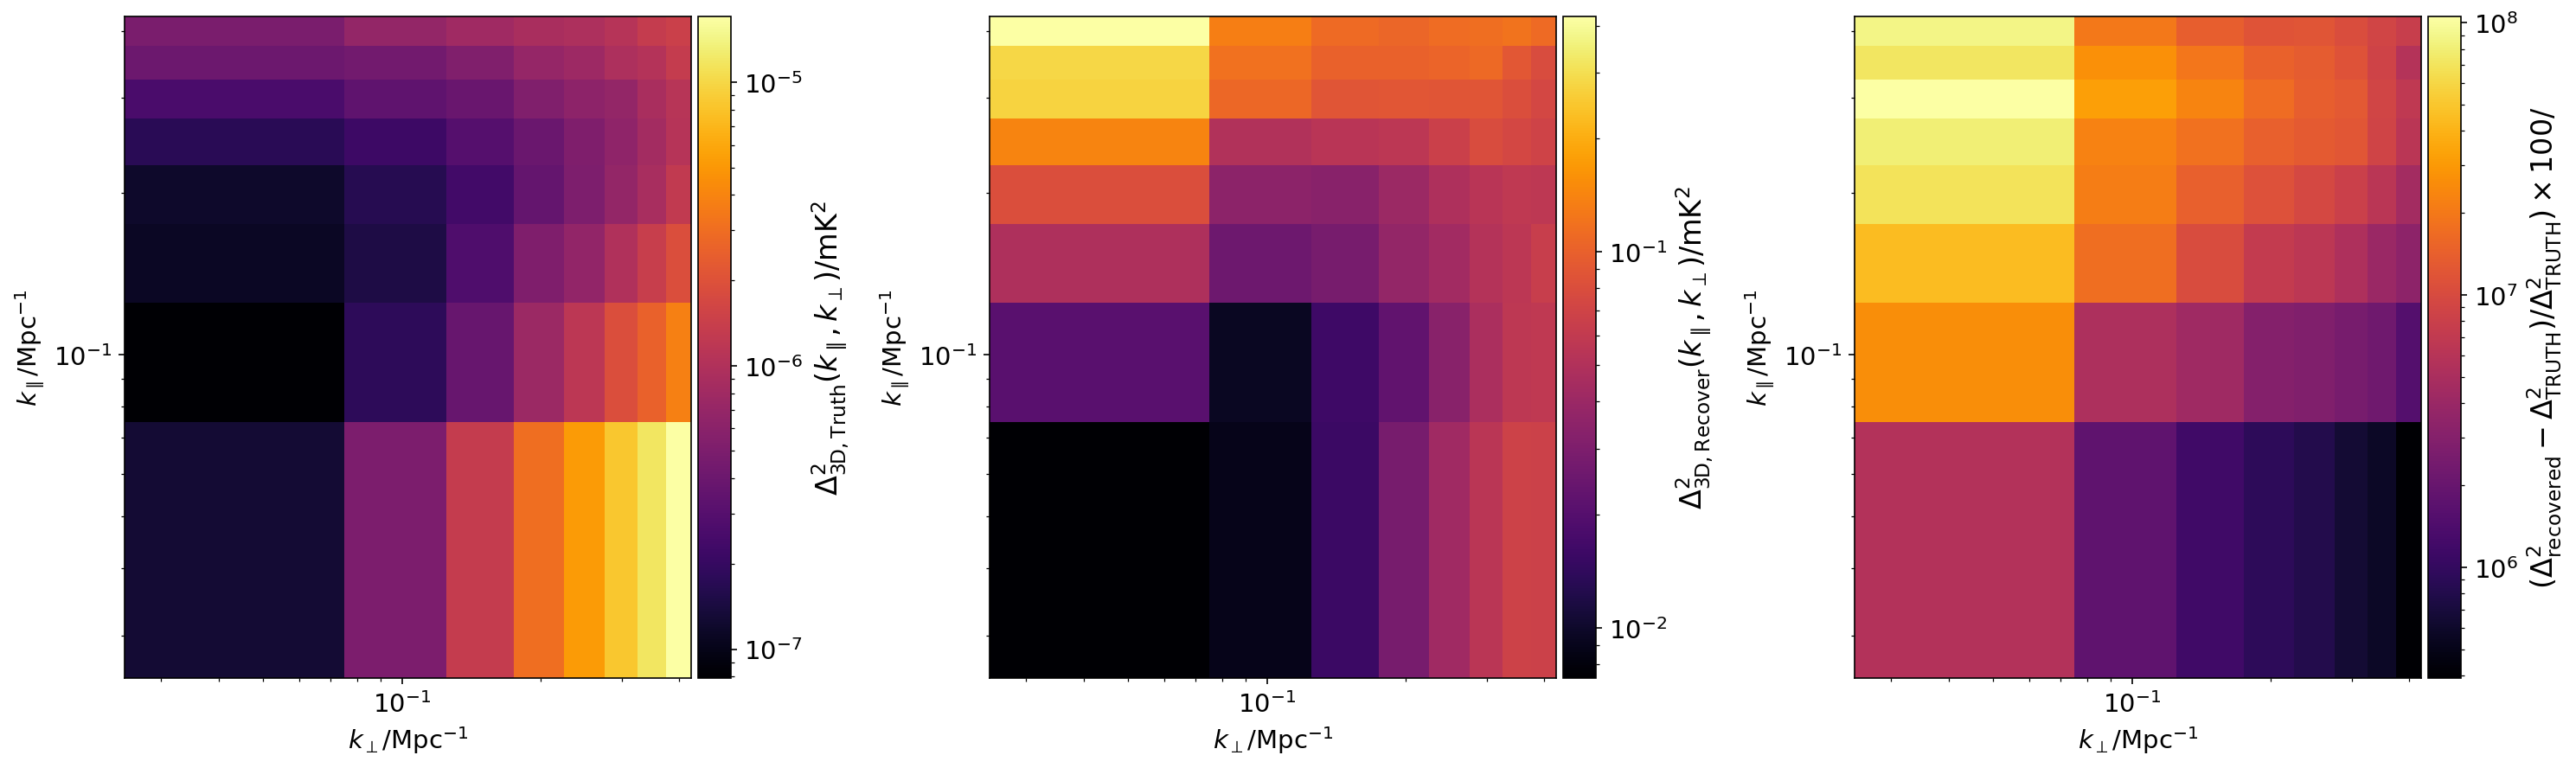

In [26]:
fp = interpolate.interp2d(kper, kpar, ((pp_res.T-pp_truth.T)/pp_truth.T)*100, kind='linear')
CC_diff = fp(kper,kpar)

norm_diff = colors.LogNorm(vmin=CC_diff[np.isfinite(CC_diff)].min(), vmax=CC_diff[np.isfinite(CC_diff)].max()) if plotting_scale['z']=='log' else None 

fig, ax = plt.subplots(figsize=(fig_width*3, fig_height),
                       nrows=1, ncols=3,)
    

pcm_truth = ax[0].pcolormesh(kper, kpar, CC_truth, norm=norm_truth, cmap='inferno')
cbar= plt.colorbar(pcm_truth, ax=ax[0], pad=0.01)
cbar.set_label(r'$\Delta_{\rm 3D, Truth}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[0].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[0].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0].set_xscale(plotting_scale['x'])
ax[0].set_yscale(plotting_scale['y'])

pcm_res = ax[1].pcolormesh(kper, kpar, CC_res, norm=norm_res, cmap='inferno')
cbar= plt.colorbar(pcm_res, ax=ax[1], pad=0.01)
cbar.set_label(r'$\Delta_{\rm 3D, Recover}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[1].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1].set_xscale(plotting_scale['x'])
ax[1].set_yscale(plotting_scale['y'])

pcm_res = ax[2].pcolormesh(kper, kpar, CC_diff, norm=norm_diff, cmap='inferno')
cbar= plt.colorbar(pcm_res, ax=ax[2], pad=0.01)
cbar.set_label(r'$(\Delta_{\rm recovered}^2-\Delta_{\rm TRUTH}^2)/\Delta_{\rm TRUTH}^2) \times 100 /$', size=16) 
ax[2].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[2].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[2].set_xscale(plotting_scale['x'])
ax[2].set_yscale(plotting_scale['y'])
plt.tight_layout()
plt.savefig(base + 'plots/powerspec_comparsion.pdf', dpi=330)
plt.show()

Filename: /home/ppxjf3/SKAO_DATA_CHALLENGE/bright_source_removal/FastICA_1stgo_resids_allfreqs_Jybeam.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (1024, 1024, 901)   float64   
(44, 1024, 1024)


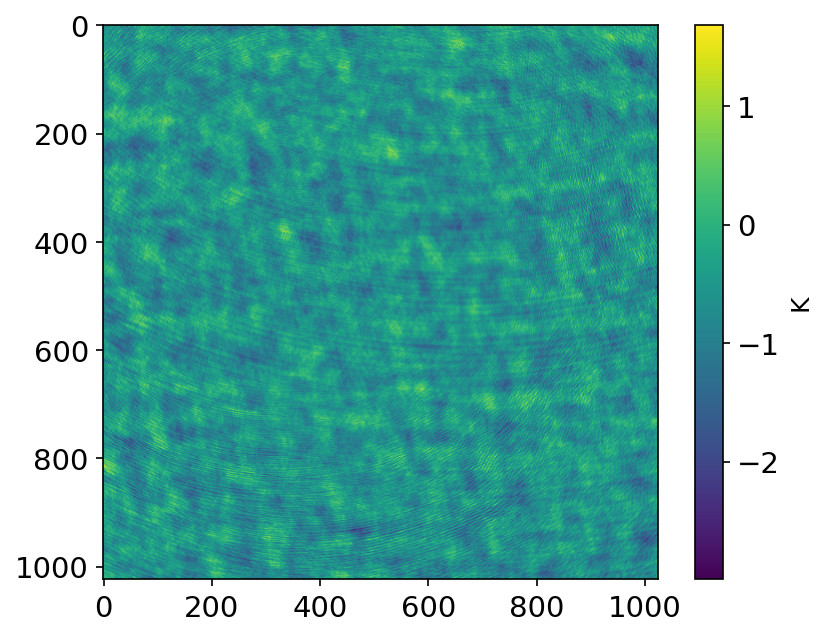

In [36]:
#make the same graph as above but for our initial results within the same frequency range
with fits.open('/home/ppxjf3/SKAO_DATA_CHALLENGE/bright_source_removal/FastICA_1stgo_resids_allfreqs_Jybeam.fits', memmap=True) as hdu:
    inital = np.array(hdu[0].data[525:569,:,:]) #10MHz centered on 166MHz
    hdu.info()
    print(inital.shape)

inital = TFromJyBeam(np.transpose(inital, (1, 2, 0)), bmaj, bmin, nu)   
plt.imshow(inital[:,:,0])
plt.colorbar(label='K')

In [ ]:
#make power spectra GPR
plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

kper, kpar, CC, norm = cyclindircal_powerspec()

pcm = plt.pcolormesh(kper, kpar, CC, norm=norm, cmap='inferno')
cbar= plt.colorbar(pcm)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
plt.xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
plt.ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
plt.xscale(plotting_scale['x'])
plt.yscale(plotting_scale['y'])
plt.show()

TypeError: cyclindircal_powerspec() missing 2 required positional arguments: 'data' and 'kbins'